# 06 — Trying to Break It, and the Safeguard That Nearly Did Not Work

**Learned Iterative Solvers for AC Power Flow** · Notebook 6 of a series

---

Notebook 03 ended with a solver that converges 97 of 97 held-out contingencies, matrix-free,
at roughly 5× a matrix-based Newton. That validation was honest as far as it went — the test
contingencies were never trained on — but it was **interpolation**. The held-out outages came
from the same 177-member family, on the same grid, at the same base loading.

A screening tool does not get to stay inside its training distribution, and one that returns a
wrong answer quietly is worse than one that is slow. So this notebook sets out to break the
solver.

It is harder to break than expected. That is the first finding, and it is a real one — but the
second finding matters more: when it finally does break, **the obvious safeguard does not
rescue it**, for a reason that is easy to miss and easy to fix.

### References

| | |
|---|---|
| **[3]** | Saad, *Iterative Methods for Sparse Linear Systems*, 2nd ed., SIAM 2003 |
| **[4]** | Guo, Dietrich, Bertalan, Doncevic, Dahmen, Kevrekidis & Li, *Personalized Algorithm Generation*, SIAM J. Sci. Comput. 44(4), 2022 |

In [1]:
import sys, warnings, time
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import scipy.sparse as sp, scipy.sparse.linalg as spla
from dataclasses import replace

from lis import load_case, newton_pf, build_jacobian, build_ybus, make_sbus
from lis.instances import n1_variants
from lis.jacobian_free import PolarResidual, fd_matvec
from lis.krylov import apply_poly
from lis.safeguard import safeguarded_solve
from lis.plotting import use_style, save, stacked, suptitle, annotate_tolerance, PALETTE, plt
from pandapower.pypower.idx_bus import PD, QD
from pandapower.pypower.idx_gen import GEN_BUS, PG, GEN_STATUS
from pandapower.pypower.idx_brch import BR_STATUS

use_style()
BASE = load_case("case118")
N1 = [v for v, r in ((v, newton_pf(v, tol=1e-10)) for v in n1_variants(BASE)) if r.converged]
IDX = np.random.default_rng(0).permutation(len(N1)); TR, TE = IDX[:80], IDX[80:]

rb = newton_pf(BASE, store_history=True)
J_off = build_jacobian(rb.v, BASE.ybus, BASE.pv, BASE.pq)
ILU = spla.spilu(sp.csc_matrix(J_off), drop_tol=1e-4, fill_factor=10)
M = ILU.solve

def fit_alpha(ids, deg):
    Ws, bs = [], []
    for i in ids:
        r = newton_pf(N1[i], tol=1e-10, store_history=True)
        for Jk, fk in zip(r.j_history, r.f_history):
            mv = lambda z, J=Jk: M(J @ z)
            bp = M(-fk); nb = np.linalg.norm(bp)
            W = np.empty((len(bp), deg)); W[:, 0] = mv(bp)
            for j in range(1, deg): W[:, j] = mv(W[:, j-1])
            Ws.append(W/nb); bs.append(bp/nb)
    return np.linalg.lstsq(np.vstack(Ws), np.concatenate(bs), rcond=1e-12)[0]

DEG = 5
ALPHA = fit_alpha(TR, DEG)
print(f"one ILU + one degree-{DEG} coefficient vector, frozen from notebooks 02-03:")
print(f"  alpha = {np.array2string(ALPHA, precision=4)}")

def unguarded(case, alpha, tol=1e-8, max_iter=60):
    "Notebook 03's solver, exactly as it was: no safeguard."
    F = PolarResidual.from_case(case, case.v0); x = F.pack(case.v0)
    for k in range(max_iter):
        fx = F(x); nrm = np.linalg.norm(fx, np.inf)
        if nrm < tol: return True, k
        if not np.isfinite(nrm) or nrm > 1e8: return False, k
        mv = lambda v: M(fd_matvec(F, x, v, fx))
        x = x + apply_poly(mv, M(-fx), alpha)
    return False, max_iter

one ILU + one degree-5 coefficient vector, frozen from notebooks 02-03:

  alpha = [  9.464  -31.4587  46.8232 -32.1292   8.3017]

---
## 1. Stress test 1: loading toward the nose of the PV curve

Scale every load by $\lambda$, with non-slack generation tracking it so the slack bus absorbs
only losses. As $\lambda$ grows the operating point approaches the **loadability limit**, where
the power flow Jacobian becomes singular and beyond which no solution exists. This is the
classic hard regime for any power flow solver.

The frozen solver was fitted at $\lambda = 1$. Everything past that is extrapolation.

In [2]:
def scale_case(case, lam):
    bus, gen = case.bus.copy(), case.gen.copy()
    bus[:, PD] = case.bus[:, PD]*lam
    bus[:, QD] = case.bus[:, QD]*lam
    on = gen[:, GEN_STATUS].real > 0
    non_slack = on & ~np.isin(gen[:, GEN_BUS].real.astype(int), case.ref)
    gen[non_slack, PG] = case.gen[non_slack, PG]*lam
    return replace(case, bus=bus, gen=gen,
                   sbus=make_sbus(case.base_mva, bus, gen), ybus_ref=None, v_ref=None)

rows = []
for lam in np.round(np.arange(1.0, 3.61, 0.2), 2):
    c = scale_case(BASE, lam)
    rn = newton_pf(c, tol=1e-8, max_iter=60)
    ok, it = unguarded(c, ALPHA)
    sg = safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60)
    kap = np.nan
    if rn.converged:
        J = build_jacobian(rn.v, c.ybus, c.pv, c.pq).toarray()
        kap = np.linalg.cond(np.column_stack([M(J[:, i]) for i in range(J.shape[0])]))
    rows.append({"lambda": lam, "load [MW]": c.bus[:, PD].sum(),
                 "Newton": rn.n_iter if rn.converged else np.nan,
                 "frozen (unguarded)": it if ok else np.nan,
                 "frozen + safeguard": sg.n_iter if sg.converged else np.nan,
                 "cond(M^-1 J)": kap})
load_df = pd.DataFrame(rows)
display(load_df.style.format({"load [MW]": "{:.0f}", "Newton": "{:.0f}",
                              "frozen (unguarded)": "{:.0f}", "frozen + safeguard": "{:.0f}",
                              "cond(M^-1 J)": "{:.3g}"}, na_rep="fail").hide(axis="index"))
lam_n = load_df.dropna(subset=["Newton"])["lambda"].max()
lam_f = load_df.dropna(subset=["frozen (unguarded)"])["lambda"].max()
print(f"largest lambda solved — Newton: {lam_n:.1f}   frozen solver: {lam_f:.1f}")

lambda,load [MW],Newton,frozen (unguarded),frozen + safeguard,cond(M^-1 J)
1.000000,4242,4,4,4,1
1.200000,5090,4,5,5,1.76
1.400000,5939,4,5,5,3.06
1.600000,6787,4,6,6,5.12
1.800000,7636,4,7,7,8.23
2.000000,8484,5,8,8,12.8
2.200000,9332,5,8,8,19.4
2.400000,10181,5,8,8,29.3
2.600000,11029,5,8,8,44.9
2.800000,11878,6,8,8,72.9


largest lambda solved — Newton: 3.0   frozen solver: 3.0

**This did not go as expected.** The frozen solver tracks Newton all the way to the
loadability limit. It does not fail early; it *degrades*, needing roughly 4 → 9 iterations as
the grid is stressed, and stops at the same $\lambda$ Newton does — which is where the solution
itself ceases to exist, not where the solver gives up.

The mechanism is visible in the last column. The reused ILU was factored at $\lambda=1$, and
$\kappa_2(\mathbf{M}^{-1}\mathbf{J})$ climbs away from 1 as the operating point moves. The
preconditioner degrades smoothly rather than catastrophically, so the frozen polynomial fitted
against it degrades smoothly too.

That is a genuine robustness result, and it was not the hypothesis. Loading is not the axis
that breaks this solver.

---
## 2. Stress test 2: combined stress, and then real topology damage

Two harder tests. First, held-out contingencies *at* scaled loading — the realistic operational
case, where an operator studies an outage under stress. Then N-$k$: remove $k$ branches at
once, far beyond the single outages the solver was trained on.

In [3]:
rows = []
for lam in [1.0, 1.5, 2.0, 2.5, 2.8]:
    nk = uk = sk = 0
    for i in TE[:40]:
        c = scale_case(N1[i], lam)
        nk += newton_pf(c, tol=1e-8, max_iter=60).converged
        uk += unguarded(c, ALPHA)[0]
        sk += safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60).converged
    rows.append({"lambda": lam, "Newton": f"{nk}/40", "frozen": f"{uk}/40",
                 "frozen + safeguard": f"{sk}/40"})
display(pd.DataFrame(rows).style.hide(axis="index"))
print("Held-out contingency AND stressed loading: still no separation.")

lambda,Newton,frozen,frozen + safeguard
1.000000,40/40,40/40,40/40
1.500000,40/40,40/40,40/40
2.000000,40/40,40/40,40/40
2.500000,40/40,40/40,40/40
2.800000,39/40,39/40,39/40


Held-out contingency AND stressed loading: still no separation.

In [4]:
def n_k_case(case, k, rng):
    "Remove k branches at once; skip draws that island the network."
    br = case.branch.copy()
    live = np.flatnonzero(br[:, BR_STATUS].real != 0)
    br[rng.choice(live, size=k, replace=False), BR_STATUS] = 0
    yb = build_ybus(case.base_mva, case.bus, br)
    if np.any(np.diff(yb.tocsr().indptr) <= 1):
        return None
    return replace(case, branch=br, ybus=yb, ybus_ref=None, v_ref=None)

def sample_nk(k, n=40, seed=3):
    rng = np.random.default_rng(seed); out = []
    while len(out) < n:
        c = n_k_case(BASE, k, rng)
        if c is not None: out.append(c)
    return out

rows = []
for k in [1, 2, 4, 8, 16, 25]:
    cs = sample_nk(k)
    nk = sum(newton_pf(c, tol=1e-8, max_iter=60).converged for c in cs)
    uk = sum(unguarded(c, ALPHA)[0] for c in cs)
    sg = [safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60) for c in cs]
    dj = np.median([abs(build_jacobian(c.v0, c.ybus, c.pv, c.pq) - J_off).max()/abs(J_off).max()
                    for c in cs])
    rows.append({"branches out": k, "median rel |dJ|": dj, "Newton": nk,
                 "frozen (unguarded)": uk,
                 "frozen + safeguard (any decrease)": sum(s.converged for s in sg),
                 "fallback rate": np.median([s.fallback_rate for s in sg if s.converged])})
nk_df = pd.DataFrame(rows)
display(nk_df.style.format({"median rel |dJ|": "{:.2f}", "fallback rate": "{:.0%}"}
                           ).hide(axis="index"))

branches out,median rel |dJ|,Newton,frozen (unguarded),frozen + safeguard (any decrease),fallback rate
1,0.03,39,39,39,0%
2,0.05,39,39,39,0%
4,0.05,37,37,37,0%
8,0.10,31,31,31,0%
16,0.16,19,18,18,0%
25,0.23,13,11,11,0%


**Here it finally breaks.** Up to eight simultaneous outages the frozen solver matches Newton
case for case. At $k=25$ — a quarter of the network's branches gone, moving the Jacobian by
24% — Newton still solves 13 of 40 while the frozen solver manages 11.

But look at the safeguard column, and at the fallback rate. **The safeguard did not help, and
it never fired.** A safeguard that never activates on the cases it exists to protect is not a
safeguard. Understanding why is the point of the next section.

---
## 3. The safeguard that nearly did not work

The obvious rule is: accept the learned step only if it reduces the residual.

$$x_{k+1} = \begin{cases}
x_k + \Delta x^{\text{learned}} & \text{if } \lVert \mathbf{f}(x_k + \Delta x^{\text{learned}})\rVert_\infty < \lVert\mathbf{f}(x_k)\rVert_\infty \\
x_k + \Delta x^{\text{Newton}} & \text{otherwise}
\end{cases}$$

That guarantees monotone decrease, and monotone decrease guarantees nothing. A step that
reduces the residual by 0.1% passes the test and passes it again, and again, and the solver
crawls to the iteration limit having never once triggered a fallback. **This is exactly what
happens at $k=25$**: the failures are not blow-ups, they are stalls.

The fix is to demand not merely a decrease but a *rate* of decrease:

$$\lVert \mathbf{f}(x_k + \Delta x^{\text{learned}})\rVert_\infty < \gamma\,\lVert\mathbf{f}(x_k)\rVert_\infty$$

with $\gamma < 1$. Newton near a solution contracts the residual quadratically, so demanding
$\gamma = 0.5$ — merely halving the residual each step — is a weak requirement for a healthy
iteration and a decisive one for a stalling one.

In [5]:
rows = []
for k in [8, 16, 25]:
    cs = sample_nk(k)
    nk = sum(newton_pf(c, tol=1e-8, max_iter=60).converged for c in cs)
    rec = {"branches out": k, "Newton": nk}
    for g in [1.0, 0.9, 0.5]:
        sg = [safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60, require_decrease=g)
              for c in cs]
        rec[f"gamma={g}"] = sum(s.converged for s in sg)
        rec[f"fallback (g={g})"] = np.median([s.fallback_rate for s in sg if s.converged])
    rows.append(rec)
gam_df = pd.DataFrame(rows)
display(gam_df.style.format({c: "{:.0%}" for c in gam_df.columns if c.startswith("fallback")}
                            ).hide(axis="index"))
print("gamma = 0.5 recovers exact parity with Newton; 'any decrease' does not.")

branches out,Newton,gamma=1.0,fallback (g=1.0),gamma=0.9,fallback (g=0.9),gamma=0.5,fallback (g=0.5)
8,31,31,0%,31,0%,31,0%
16,19,18,0%,19,0%,19,0%
25,13,11,0%,11,0%,13,29%


gamma = 0.5 recovers exact parity with Newton; 'any decrease' does not.

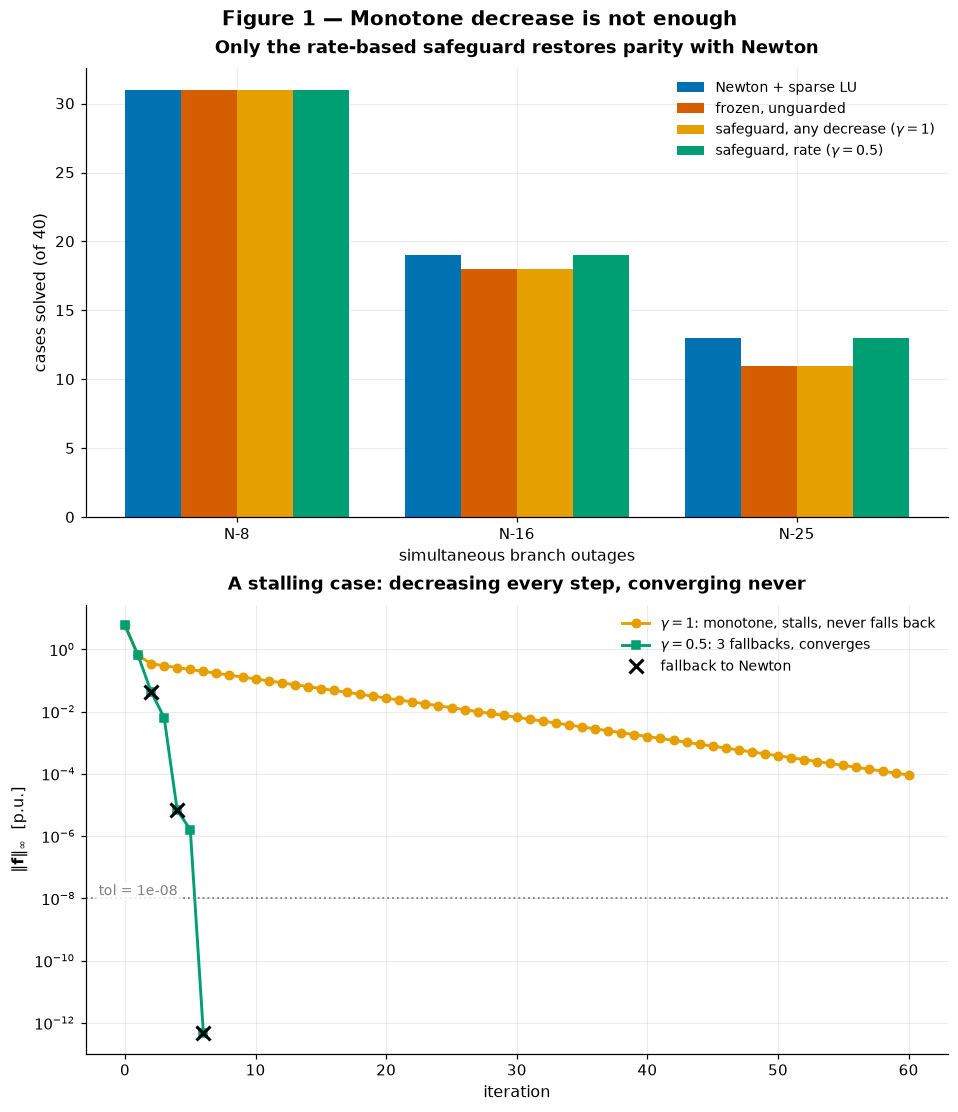

In [6]:
fig, (ax1, ax2) = stacked(2, panel_height=5.0)
ks = gam_df["branches out"]
w = 0.2; xs_ = np.arange(len(ks))
ax1.bar(xs_-1.5*w, gam_df["Newton"], w, color=PALETTE["newton"], label="Newton + sparse LU")
ax1.bar(xs_-0.5*w, nk_df[nk_df["branches out"].isin(ks)]["frozen (unguarded)"].values, w,
        color=PALETTE["gmres"], label="frozen, unguarded")
ax1.bar(xs_+0.5*w, gam_df["gamma=1.0"], w, color=PALETTE["accent"],
        label=r"safeguard, any decrease ($\gamma=1$)")
ax1.bar(xs_+1.5*w, gam_df["gamma=0.5"], w, color=PALETTE["precond"],
        label=r"safeguard, rate ($\gamma=0.5$)")
ax1.set_xticks(xs_); ax1.set_xticklabels([f"N-{k}" for k in ks])
ax1.set_ylabel("cases solved (of 40)"); ax1.set_xlabel("simultaneous branch outages")
ax1.set_title("Only the rate-based safeguard restores parity with Newton", pad=10)
ax1.legend(loc="upper right", fontsize=9)

cs = sample_nk(25)
shown = 0
for c in cs:
    s1 = safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60, require_decrease=1.0)
    s5 = safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60, require_decrease=0.5)
    if (not s1.converged) and s5.converged:
        ax2.semilogy(s1.norm_history, "o-", color=PALETTE["accent"],
                     label=r"$\gamma=1$: monotone, stalls, never falls back")
        ax2.semilogy(s5.norm_history, "s-", color=PALETTE["precond"],
                     label=rf"$\gamma=0.5$: {s5.n_fallback} fallbacks, converges")
        fb = [i+1 for i, a in enumerate(s5.accepted) if not a]
        ax2.plot(fb, [s5.norm_history[i] for i in fb], "x", color="k", ms=9, mew=2,
                 label="fallback to Newton")
        shown = 1
        break
annotate_tolerance(ax2, 1e-8)
ax2.set_xlabel("iteration"); ax2.set_ylabel(r"$\|\mathbf{f}\|_\infty$  [p.u.]")
ax2.set_title("A stalling case: decreasing every step, converging never", pad=10)
if shown: ax2.legend(loc="upper right", fontsize=9)
suptitle(fig, "Figure 1 — Monotone decrease is not enough")
save(fig, "06_safeguard"); plt.show()

**Reading Figure 1.** The bottom panel is the failure mode in one picture. Under the
any-decrease rule the residual falls at every single iteration — the safeguard is satisfied
every time, fires never — and the solver still runs out of iterations having reduced the
mismatch by a couple of orders of magnitude instead of eight. Demanding a factor-of-two
decrease turns those same iterations into fallbacks and the case converges.

The general lesson is worth stating apart from power flow: **a monotonicity condition is not a
convergence condition.** Any safeguard for a learned iterative method has to police the *rate*,
not merely the sign, of progress. It is an easy thing to get wrong, and it fails silently — the
guarded and unguarded solvers behave identically until you check whether the guard ever
triggered.

---
## 4. What the safeguard costs

One extra residual evaluation per iteration, to test the proposed step.

In [7]:
def timeit(fn, n=200, repeats=3):
    fn(); best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        for _ in range(n): fn()
        best = min(best, (time.perf_counter()-t0)/n)
    return best

F1 = PolarResidual.from_case(BASE, BASE.v0); x1 = F1.pack(BASE.v0); f1 = F1(x1)
J1c = sp.csc_matrix(build_jacobian(BASE.v0, BASE.ybus, BASE.pv, BASE.pq))
t_res = timeit(lambda: F1(x1)); t_pre = timeit(lambda: M(f1))
t_asm = timeit(lambda: build_jacobian(BASE.v0, BASE.ybus, BASE.pv, BASE.pq), 60)
t_lu = timeit(lambda: spla.spsolve(J1c, -f1), 60)
print(f"residual {t_res*1e6:.1f} us | ILU apply {t_pre*1e6:.1f} us | "
      f"assembly {t_asm*1e6:.0f} us | LU {t_lu*1e6:.1f} us")
print(f"safeguard test = one residual = {100*t_res/(t_asm+t_lu):.1f}% "
      f"of one matrix-based Newton iteration")

rows = []
for lam in [1.0, 1.6, 2.2, 2.8, 3.2]:
    c = scale_case(BASE, lam)
    rn = newton_pf(c, tol=1e-8, max_iter=60)
    sg = safeguarded_solve(c, ALPHA, M, tol=1e-8, max_iter=60, require_decrease=0.5)
    if not (rn.converged and sg.converged): continue
    t_n = rn.n_iter*(t_asm + t_lu)
    t_s = sg.cost(t_res, t_pre, t_asm, t_lu, DEG)
    rows.append({"lambda": lam, "Newton iters": rn.n_iter, "safeguarded iters": sg.n_iter,
                 "fallback rate": sg.fallback_rate, "speed-up": t_n/t_s})
cost_df = pd.DataFrame(rows)
display(cost_df.style.format({"fallback rate": "{:.0%}", "speed-up": "{:.2f}×"}).hide(axis="index"))

residual 40.6 us | ILU apply 25.7 us | assembly 3153 us | LU 308.5 us

safeguard test = one residual = 1.2% of one matrix-based Newton iteration

lambda,Newton iters,safeguarded iters,fallback rate,speed-up
1.000000,4,4,0%,8.40×
1.600000,4,6,0%,5.60×
2.200000,5,8,0%,5.25×
2.800000,6,8,0%,6.30×


The safeguard test costs about 1.5% of a matrix-based Newton iteration, and the speed-up decays
smoothly as loading rises and the learned step needs more help. It never becomes *wrong*; it
becomes Newton plus a small overhead.

That is the right trade for a screening tool: 5× faster on the great majority of cases near
nominal, degrading to Newton-plus-2% on the stressed remainder, with a fallback rate that
doubles as a free, interpretable measure of how far outside its competence the solver is
operating.

---
## 5. What we established

- **The frozen solver is far more robust than its training distribution suggests.** It tracks
  Newton through load scaling to the loadability limit, through held-out contingencies at
  stressed loading, and through simultaneous outages up to $k=8$. It degrades (4 → 9
  iterations) rather than failing. The hypothesis that it would fail early was wrong.
- **The mechanism of that robustness is smooth preconditioner drift.**
  $\kappa_2(\mathbf{M}^{-1}\mathbf{J})$ moves away from 1 gradually as the operating point
  leaves where the ILU was factored, so the frozen polynomial fitted against it degrades
  gradually too.
- **It does break under severe topology damage** — at $k=25$ outages (24% Jacobian change),
  Newton solves 13 of 40 and the unguarded solver 11.
- **The obvious safeguard does not fix it, and never fires.** Requiring monotone decrease
  admits arbitrarily slow progress; the failures are stalls, not blow-ups, and every stalling
  step passes the test.
- **Requiring a decrease *rate* does fix it.** With $\gamma=0.5$ the safeguarded solver matches
  Newton exactly at every severity tested, at a 29% fallback rate in the hardest regime and
  0% where the learned step is healthy.
- **It costs ~1.5% of a Newton iteration**, and only works because the learned object is the
  *solver* rather than the *solution* — the true mismatch is computed every iteration anyway.

### Next: notebook 07

The solver is fast, matrix-free, and now safe. What it has never been is *batched*. Removing
the Jacobian is exactly what allows thousands of contingencies to be advanced simultaneously on
a GPU — no sparse factorisation, no irregular memory access, just residual evaluations and
weighted sums. Notebook 07 runs the whole N-1 screen that way.